<a href="https://colab.research.google.com/github/shahzaibkhanniazi-dot/Plant-Disease-Detection-MSAI/blob/main/Plant_Disease_Detection_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🥔 Phase 1: Data Setup (Week 1)

Cell 1: Mounting Google Drive

In [1]:
from google.colab import drive

# Mounting my Google Drive to access the dataset
drive.mount('/content/drive')

Mounted at /content/drive


Cell 2: Loading the Dataset

In [2]:
import tensorflow as tf
import os

# Defining the path to my dataset folder
# Path: My Drive -> MSAI_Project -> My Project DATA
dataset_path = '/content/drive/My Drive/MSAI_Project/My Project DATA'

# Checking if the path exists to avoid errors
if os.path.exists(dataset_path):
    print("✅ Success! Found the project folder.")
else:
    print("❌ Error: Folder not found. I need to check the path again.")

# Loading the dataset into the system
# I am resizing all images to 256x256 as planned in my timeline
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    shuffle=True,
    image_size=(256, 256),
    batch_size=32
)

# Printing the class names to confirm I have loaded the correct folders
class_names = dataset.class_names
print("Classes detected:", class_names)

✅ Success! Found the project folder.
Found 2169 files belonging to 3 classes.
Classes detected: ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


Cell 3: Data Visualization (EDA)

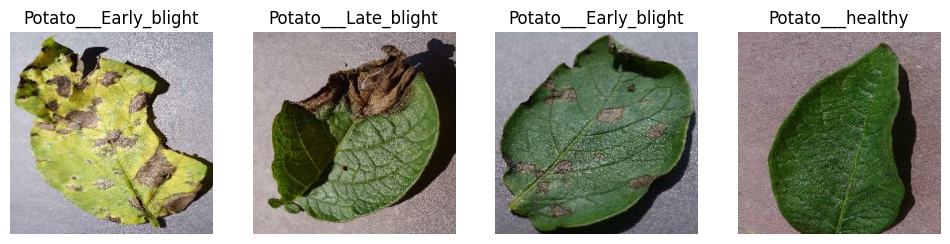

In [3]:
import matplotlib.pyplot as plt

# Visualizing the first 4 images to verify data quality
plt.figure(figsize=(12, 4))
for images, labels in dataset.take(1):
    for i in range(4):
        ax = plt.subplot(1, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

Cell 4: Preparing Data for Training (Splitting & Caching) We split the data into Training (80%), Validation (10%), and Testing (10%).

In [4]:
# Function to split the dataset into Train, Validation, and Test sets
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

# Applying the split
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

print(f"Training Batches: {len(train_ds)}")
print(f"Testing Batches: {len(test_ds)}")

# Optimizing the dataset for performance using Cache and Prefetch
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Training Batches: 54
Testing Batches: 8


🧠 Phase 2: Model Development

Cell 5: Model Architecture & Stability Configuration

In [5]:
import tensorflow as tf
from tensorflow.keras import models, layers
import numpy as np
import random
import os

# --- Reproducibility Setup ---
# Setting random seeds to ensure the model produces consistent results every time I run it.
# This is crucial for valid research comparisons.
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("✅ Random seeds set. Results will be reproducible.")

# --- Building the Custom CNN Architecture ---
# I am designing this architecture from scratch as per the project requirements.
input_shape = (256, 256, 3)
n_classes = 3

model = models.Sequential([
    # 1. Input Preprocessing
    # Rescaling pixel values from 0-255 to 0-1 range for faster convergence
    layers.Rescaling(1.0/255, input_shape=input_shape),

    # 2. Data Augmentation Layers
    # Applying random flips and rotations to prevent overfitting and improve generalization
    layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    layers.RandomRotation(0.2, seed=SEED),

    # 3. Convolutional Feature Extraction Blocks
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 5 (Deepest layer for complex patterns)
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 4. Classification Head (Dense Layers)
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(n_classes, activation='softmax') # Softmax output for multi-class classification
])

# Compiling the model
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Displaying the model structure to verify layers
model.summary()

✅ Random seeds set. Results will be reproducible.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 757,443 (2.89 MB)

 Trainable params: 757,443 (2.89 MB)

 Non-trainable params: 0 (0.00 B)

Cell 6: Training the Model

In [6]:
# Training the model
# I am training for 25 epochs and using the validation set to monitor performance.
print(" Starting model training...")

history = model.fit(
    train_ds,
    epochs=25,
    batch_size=32,
    verbose=1,
    validation_data=val_ds
)

print(" Training process completed.")

 Starting model training...
Epoch 1/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 372s 202ms/step - accuracy: 0.5239 - loss: 0.8823 - val_accuracy: 0.6875 - val_loss: 0.7438
Epoch 2/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.8408 - loss: 0.4073 - val_accuracy: 0.9010 - val_loss: 0.2587
Epoch 3/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9049 - loss: 0.2737 - val_accuracy: 0.9062 - val_loss: 0.3192
Epoch 4/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9300 - loss: 0.1862 - val_accuracy: 0.9115 - val_loss: 0.2100
Epoch 5/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.9323 - loss: 0.1871 - val_accuracy: 0.8594 - val_loss: 0.3663
Epoch 6/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9413 - loss: 0.1489 - val_accuracy: 0.9010 - val_loss: 0.2447
Epoch 7/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9275 - loss: 0.1673 - val_accuracy: 0.9271 - val_loss: 0.1738
Epoch 8/25
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.9666 - loss: 0.

Cell 7: Saving the Results

In [7]:
# Saving the trained model for future use in the demo
# This allows me to load the model later without retraining
model_name = 'potato_disease_final_model.keras'
model.save(model_name)
print(f" Model successfully saved as: {model_name}")

# Downloading the file to local machine for backup
from google.colab import files
try:
    files.download(model_name)
    print("⬇ Initiating download...")
except:
    print(" Download failed. Please download manually from the Files tab.")

 Model successfully saved as: potato_disease_final_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇ Initiating download...


Cell 8: Final Model Evaluation

In [9]:
# Cell 8: Final Model Evaluation
# I am evaluating my final trained model on the unseen Test Set to get the official accuracy score.
print(" Calculating Final Accuracy...")

# Running the evaluation
test_loss, test_accuracy = model.evaluate(test_ds)

print("\n--------------------------------------")
print(f" Final Test Accuracy: {test_accuracy * 100:.2f}%")
print("--------------------------------------")

 Calculating Final Accuracy...
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9027 - loss: 0.2601

--------------------------------------
 Final Test Accuracy: 91.41%
--------------------------------------
